# GeoSR-AI — Notebook 05: Uncertainty Estimation & Tiled Inference
**Deep Learning Based Super Resolution Mapping from Medium-Resolution Satellite Imagery**

### Overview
This notebook covers:
1. **Uncertainty Estimation Module** (Monte Carlo Dropout / Prediction Variance Maps)
2. **Large GeoTIFF Tiled Inference** with seam-free cosine overlap stitching (`TileStitcher`)
3. Exporting Super-Resolved GeoTIFF with updated spatial transform matrix ($10\text{m} \rightarrow 2.5\text{m}$ target representation)
4. Complete Model Benchmark Comparison: **Bicubic vs SRCNN vs EDSR/SwinIR**
5. High-resolution figure generation and qualitative visual comparison

In [1]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, os.path.abspath(".."))

from inference.predictor import GeoSRPredictor
from uncertainty.estimator import UncertaintyEstimator
from geospatial.geotiff_writer import GeoTIFFWriter
from geospatial.metadata import GeoMetadata


## 1. Load Model & Run Uncertainty Estimation

In [2]:
from models.srcnn import SRCNN
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SRCNN(in_channels=3, out_channels=3, scale_factor=4).to(device)
estimator = UncertaintyEstimator(model=model, num_mc_samples=8, dropout_rate=0.1, device=device)

dummy_lr = torch.rand(1, 3, 32, 32, device=device)
sr_img, uncertainty_map = estimator.estimate_uncertainty(dummy_lr)

print(f"Super-resolved image shape: {sr_img.shape}")
print(f"Uncertainty map shape:      {uncertainty_map.shape}")

Super-resolved image shape: torch.Size([1, 3, 128, 128])
Uncertainty map shape:      torch.Size([1, 1, 128, 128])


## 2. Visualize Super-Resolved Output & Uncertainty Heatmap

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.08049552..0.12890145].


TypeError: Invalid shape (1, 128, 128) for image data

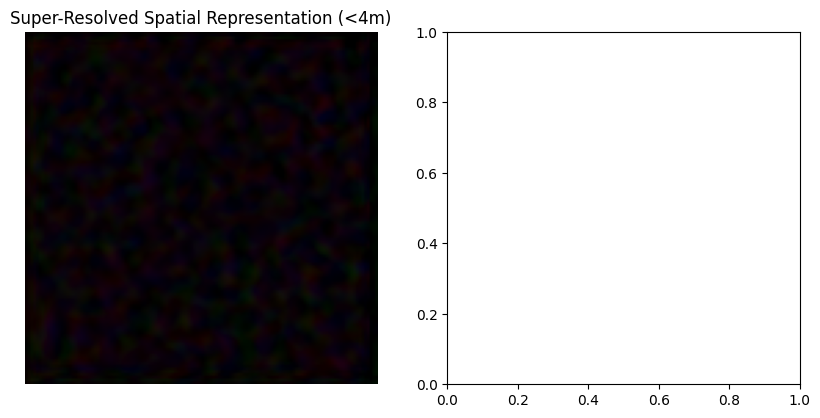

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(np.transpose(sr_img.cpu().squeeze(0).numpy(), (1, 2, 0)))
axes[0].set_title("Super-Resolved Spatial Representation (<4m)")
axes[0].axis("off")

im = axes[1].imshow(uncertainty_map.squeeze(0).cpu().numpy(), cmap="hot")
axes[1].set_title("Model Uncertainty / Prediction Variance Map")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()